# Predicción de contratación de depósitos a plazo
# Matías Toro

### Nota:
Algunos Markdowns parecieran ser -incomodamente- hechos por IA. Quiero aclarar que todos los markdows los hice yo pero le pedí a Claude que corrigiera la forma en que se presentan estos mensajes. <br>
Quería aprovechar las herramientas que ofrecen los markdowns para hacer una presentación más clara y ordenada de los resultados, pero el contenido y la interpretación de ellos son completamente míos.
<br><br>
Preferí este enfoque a mostrar markdowns simples, planos y, en general, aburridos. Además me sirvió para tener la información más ordenada y clara y así estudiar mejor. Espero que esto no sea un problema.

<span style="color:blue">Aquí hay un ejemplo de cómo le pedí a Claude que corrigiera la forma de presentar los mensajes:</span>
> "arregla este markdown para destacar elementos importantes, dar mejor visualización y entendimiento del mensaje y hacerlo, en general, más bonito aprovechando  todas las herramientas  que disponen los markwdowns. No cambies el texto, solo la forma en que se presenta."

Importo bibliotecas

In [1]:
pip install -r requirements.txt -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

leo dataset

In [3]:
df = pd.read_csv('bank.csv')

Reviso la  forma del dataset y los tipos de datos de cada columna

In [4]:
df.shape

(11162, 17)

In [5]:
df.head(6)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
5,42,management,single,tertiary,no,0,yes,yes,unknown,5,may,562,2,-1,0,unknown,yes


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        11162 non-null  int64
 1   job        11162 non-null  str  
 2   marital    11162 non-null  str  
 3   education  11162 non-null  str  
 4   default    11162 non-null  str  
 5   balance    11162 non-null  int64
 6   housing    11162 non-null  str  
 7   loan       11162 non-null  str  
 8   contact    11162 non-null  str  
 9   day        11162 non-null  int64
 10  month      11162 non-null  str  
 11  duration   11162 non-null  int64
 12  campaign   11162 non-null  int64
 13  pdays      11162 non-null  int64
 14  previous   11162 non-null  int64
 15  poutcome   11162 non-null  str  
 16  deposit    11162 non-null  str  
dtypes: int64(7), str(10)
memory usage: 1.4 MB


Algunas columnas tienen valores 'yes' y 'no', las convierto a booleanos para facilitar el análisis posterior.

In [7]:
binary_cols = ['default', 'housing', 'loan', 'deposit']

df[binary_cols] = df[binary_cols].apply(lambda col: col.map({'yes': 1, 'no': 0}))
df[binary_cols] = df[binary_cols].astype(bool)

Creo una variable `contacted_before` que indica si el cliente ha sido contactado antes.

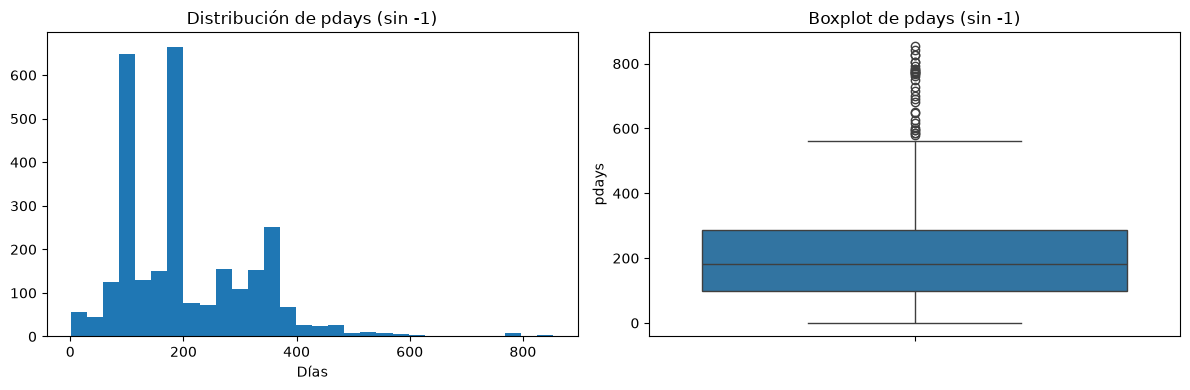

In [8]:
pdays_validos = df.loc[df['pdays'] != -1, 'pdays']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(pdays_validos, bins=30)
axes[0].set_title('Distribución de pdays (sin -1)')
axes[0].set_xlabel('Días')

sns.boxplot(y=pdays_validos, ax=axes[1])
axes[1].set_title('Boxplot de pdays (sin -1)')

plt.tight_layout()
plt.show()

También se reemplazaron esos -1 con la mediana de la columna `pdays` para evitar problemas con los valores faltantes (uso la mediana en lugar de la media ya que es más robusta frente a distribuciones asimétricas y valores extremos).

Una alternativa hubiera sido usar un valor muy alto (999) para preservar la información de 'nunca contactado'. Opté por la mediana porque ya capturamos esa señal en `previous` (0 = nunca contactado)

In [9]:
# Captura si el cliente fue contactado en campaña anterior
df['contacted_before'] = (df['pdays'] != -1).astype(int)

# Reemplaza -1 con la mediana de los valores reales
median_pdays = df.loc[df['pdays'] != -1, 'pdays'].median()
df['pdays'] = df['pdays'].replace(-1, median_pdays)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   age               11162 non-null  int64
 1   job               11162 non-null  str  
 2   marital           11162 non-null  str  
 3   education         11162 non-null  str  
 4   default           11162 non-null  bool 
 5   balance           11162 non-null  int64
 6   housing           11162 non-null  bool 
 7   loan              11162 non-null  bool 
 8   contact           11162 non-null  str  
 9   day               11162 non-null  int64
 10  month             11162 non-null  str  
 11  duration          11162 non-null  int64
 12  campaign          11162 non-null  int64
 13  pdays             11162 non-null  int64
 14  previous          11162 non-null  int64
 15  poutcome          11162 non-null  str  
 16  deposit           11162 non-null  bool 
 17  contacted_before  11162 non-null  int64
dt

In [11]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous,contacted_before
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,187.801648,0.832557,0.254256
std,11.913369,3225.413326,8.420740,347.128386,2.722077,62.404321,2.292007,0.435461
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,1.000000,0.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,182.000000,0.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,182.000000,0.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,182.000000,1.000000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000,1.000000


Reviso primero si existen valores nulos en el dataset y luego la distribución de la variable objetivo 'deposit'.

In [12]:
df.isnull().sum()

age                 0
job                 0
marital             0
education           0
default             0
balance             0
housing             0
loan                0
contact             0
day                 0
month               0
duration            0
campaign            0
pdays               0
previous            0
poutcome            0
deposit             0
contacted_before    0
dtype: int64

Reviso cuántos valores 'unknown' hay por columna categórica. No son nulos pero los trato como categoría especial. Más adelante decido si los conservo o no.

In [13]:
for col in df.select_dtypes(include=['object','str']).columns:
    n_unk = (df[col].str.lower() == 'unknown').sum()
    if n_unk > 0:
        print(f"{col}: {n_unk} unknowns ({n_unk/len(df)*100:.1f}%)")


job: 70 unknowns (0.6%)
education: 497 unknowns (4.5%)
contact: 2346 unknowns (21.0%)
poutcome: 8326 unknowns (74.6%)


No hay valores nulos en el dataset. Reviso ahora la distribución de la variable objetivo `deposit`.

deposit
False    52.62%
True     47.38%
Name: proportion, dtype: str


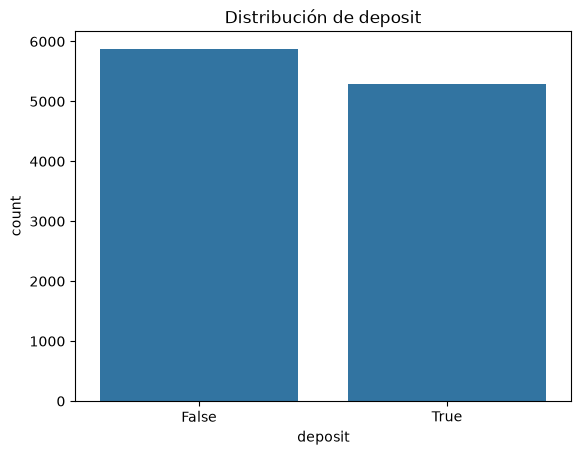

In [14]:

print(df['deposit'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

sns.countplot(x='deposit', data=df)
plt.title('Distribución de deposit')
plt.show()

Reviso  la distribución de las variables numéricas para entender mejor su comportamiento y detectar posibles outliers.

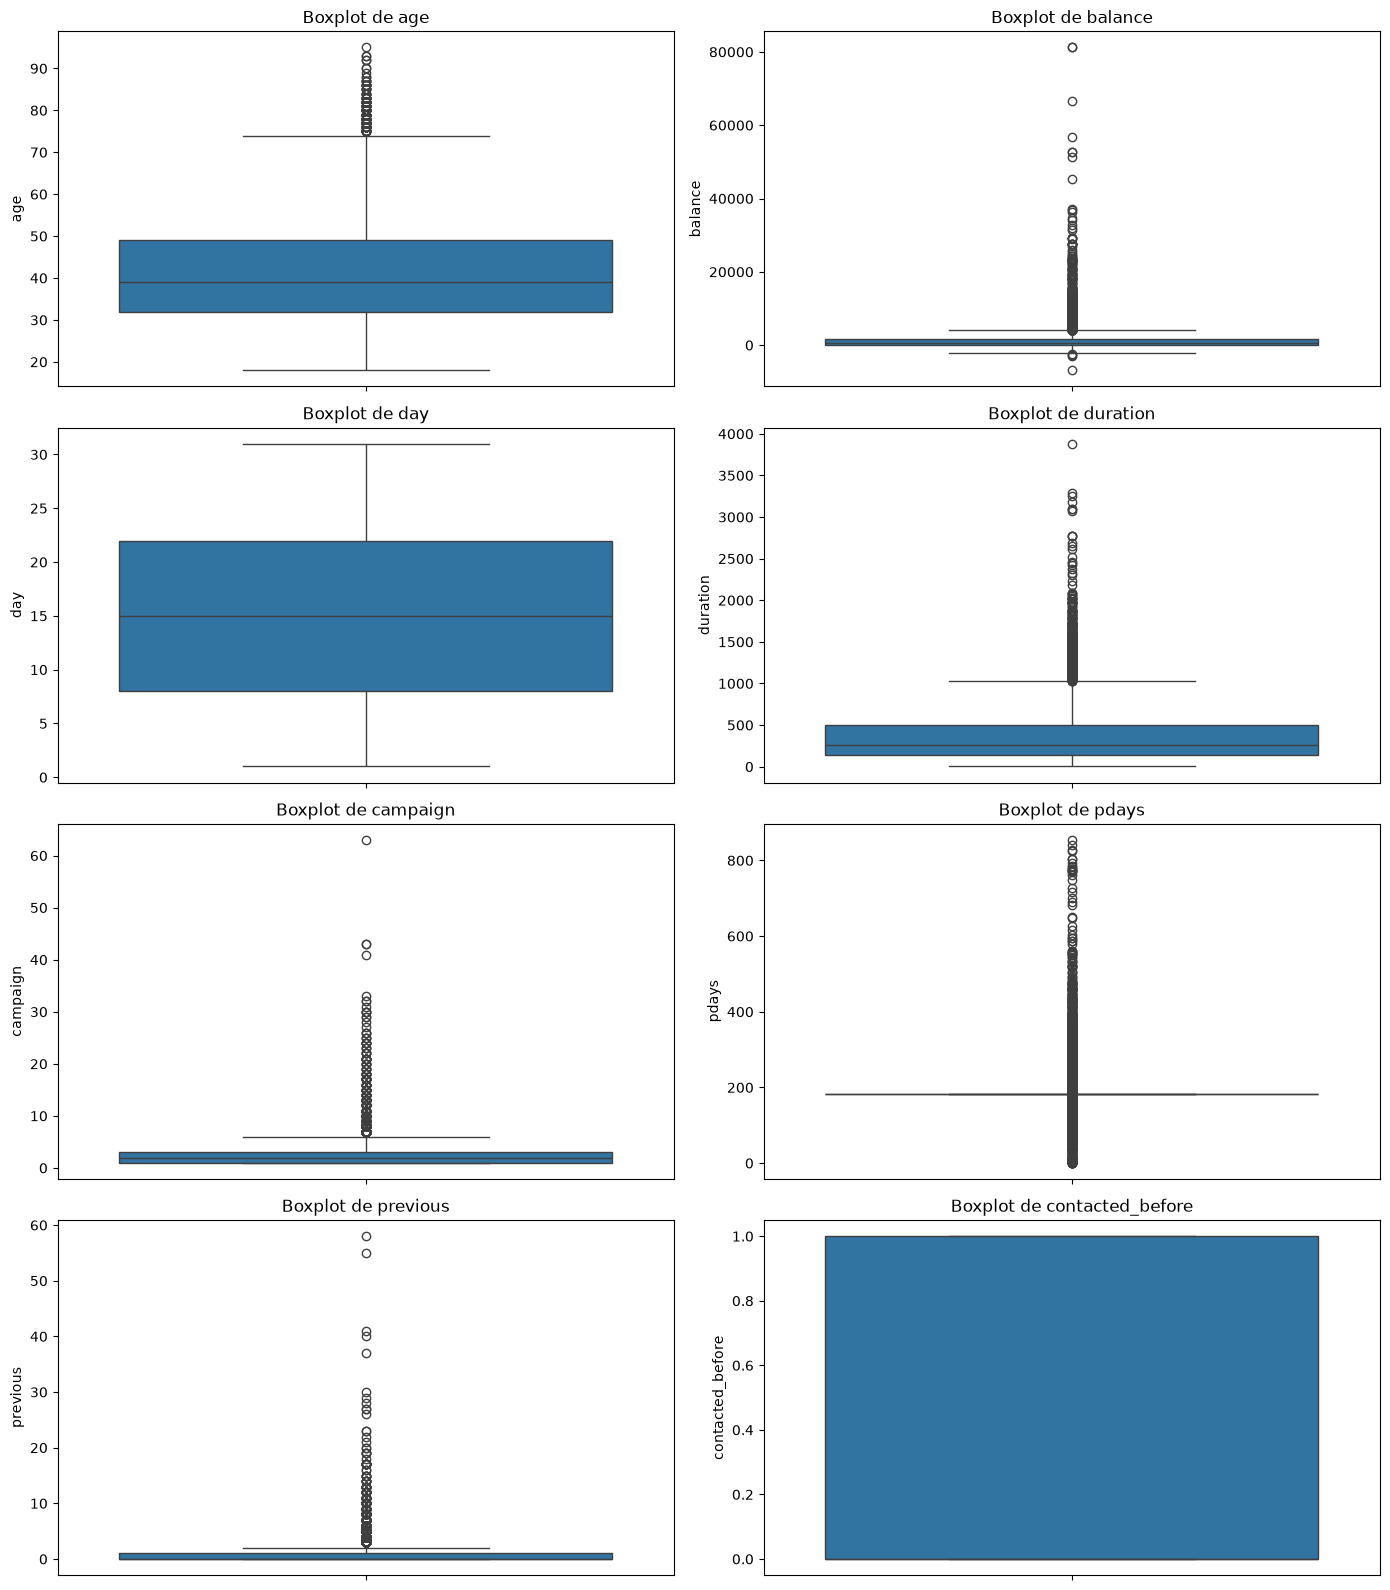

In [15]:
num_cols = df.select_dtypes(include='number').columns

#Para revisar cuantas filas y columnas hay en el dataset (num_cols), y así organizar los gráficos de manera adecuada
n_cols = 2
n_rows = (len(num_cols) + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 4))
#Esto es para pasar la matriz de ejes a una lista plana y asi iterar sobre ella usando un puro for
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=col, data=df, ax=axes[i])
    axes[i].set_title(f'Boxplot de {col}')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

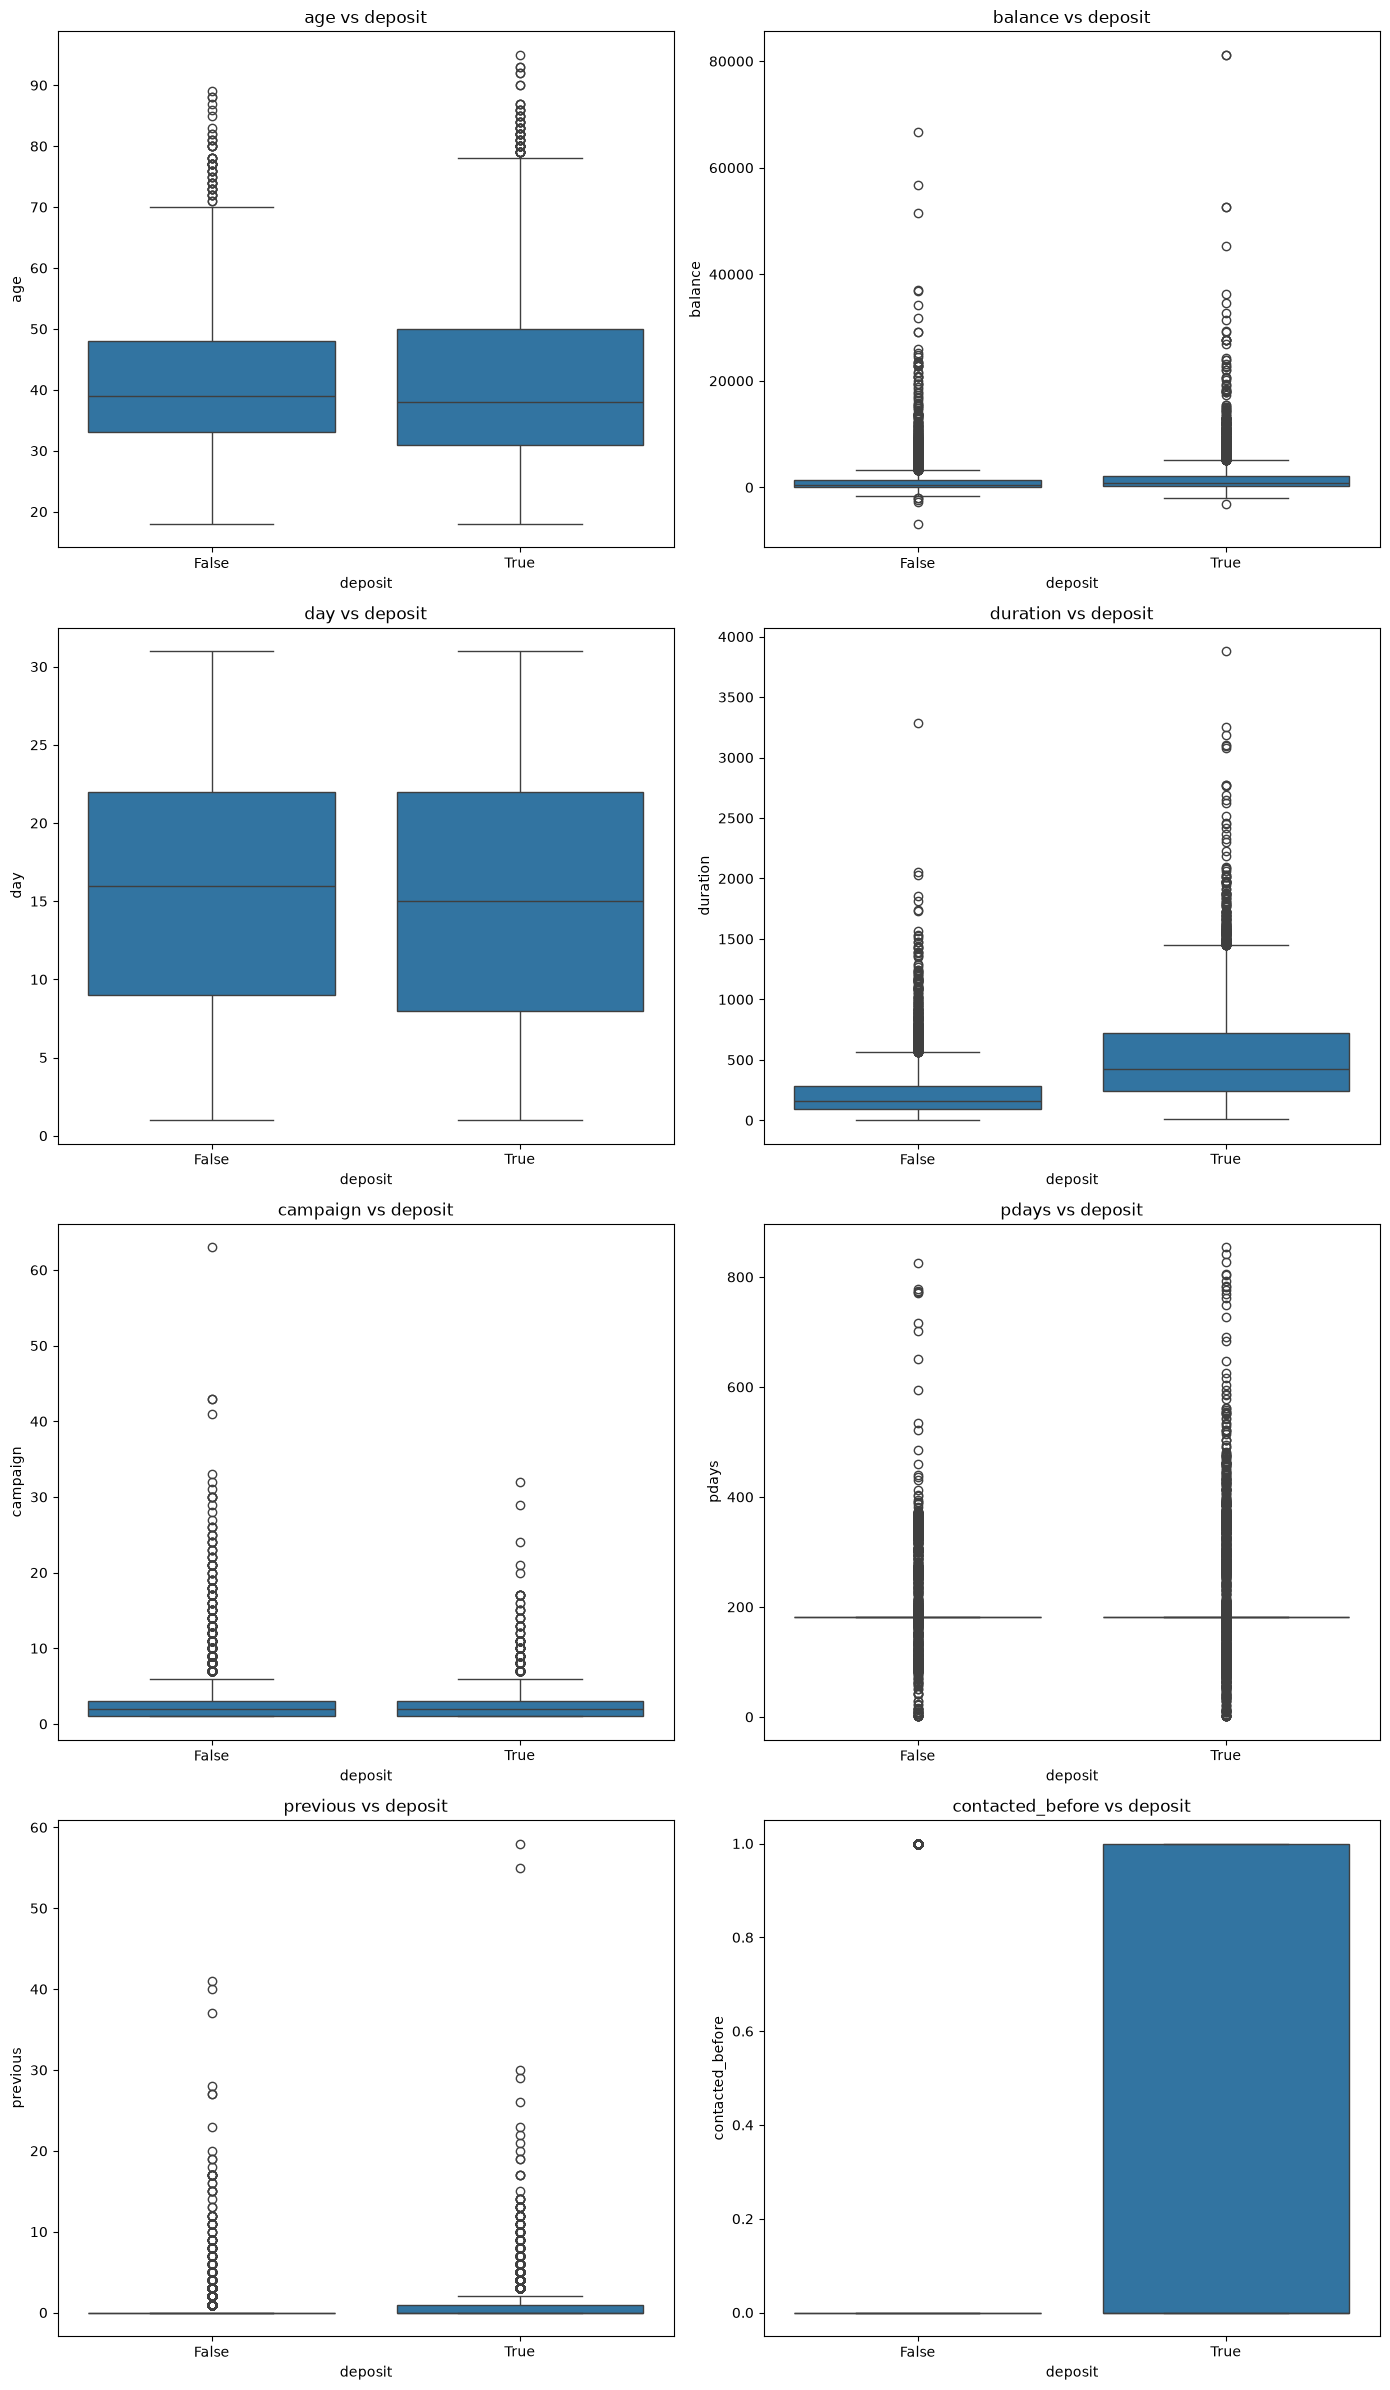

In [16]:
num_cols = df.select_dtypes(include='number').columns

fig, axes = plt.subplots((len(num_cols) + 1) // 2, 2, figsize=(14, len(num_cols) * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x='deposit', y=col, data=df, ax=axes[i])
    axes[i].set_title(f'{col} vs deposit')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()




En los boxplot veo que las cajas que podrían tener más relación con la variable objetivo 'deposit' son 'duration', 'pdays' y 'previous'. Estas variables podrían ser importantes para predecir si un cliente realizará un depósito a plazo fijo o no. Las otras variables numéricas parecen tener una distribución más uniforme y menos relación con la variable objetivo.

In [17]:
from scipy.stats import mannwhitneyu

for col in df.select_dtypes(include='number').columns:
    grupo0 = df[df['deposit'] == 0][col]
    grupo1 = df[df['deposit'] == 1][col]
    stat, p = mannwhitneyu(grupo0, grupo1)
    print(f'{col}: p-valor = {p:.4f}')

age: p-valor = 0.1990
balance: p-valor = 0.0000
day: p-valor = 0.0000
duration: p-valor = 0.0000
campaign: p-valor = 0.0000
pdays: p-valor = 0.0000
previous: p-valor = 0.0000
contacted_before: p-valor = 0.0000


In [18]:
from scipy.stats import pointbiserialr

for col in df.select_dtypes(include='number').columns:
    r, p = pointbiserialr(df['deposit'], df[col])
    print(f'{col}: correlación = {r:.4f}, p-valor = {p:.4f}')

age: correlación = 0.0349, p-valor = 0.0002
balance: correlación = 0.0811, p-valor = 0.0000
day: correlación = -0.0563, p-valor = 0.0000
duration: correlación = 0.4519, p-valor = 0.0000
campaign: correlación = -0.1281, p-valor = 0.0000
pdays: correlación = -0.0306, p-valor = 0.0012
previous: correlación = 0.1399, p-valor = 0.0000
contacted_before: correlación = 0.2308, p-valor = 0.0000


## Análisis bivariado: variables numéricas vs `deposit`

### 🔹 Mann-Whitney U Test

Evalúa si **un valor aleatorio de un grupo tiende a ser mayor que el del otro**, sin asumir distribución normal de los datos — lo cual es relevante aquí, ya que salvo `day`, ninguna variable presenta distribución normal. Lo usé para detectar si existen diferencias significativas entre clientes que realizaron un depósito y los que no.

---

### 🔹 Point Biserial Correlation

Mide la **fuerza y dirección** de la asociación entre una variable numérica y una variable binaria (como `deposit`).

| Limitación | Detalle |
|---|---|
| Normalidad | Asume distribuciones aproximadamente normales (que casi no ocurre aquí) |
| Linealidad | Asume que la relación entre variables es lineal |

---

### 🔸 Usando ambos métodos en conjunto

| Método | Qué mide |
|---|---|
| **Mann-Whitney U** | Si los valores de una variable tienden a ser sistemáticamente mayores o menores en un grupo |
| **Point Biserial** | Si existe una relación **lineal** entre la variable numérica y la variable binaria |

Cuando ambos métodos son **contradictorios**, puede indicar que la relación no es monótona.

---

### 📌 Caso destacado: `age`

El p-valor de `age` difiere entre ambos métodos, lo que sugiere que su relación con `deposit` **no es simplemente lineal ni monótona**. Es decir, no se trata de que *a mayor edad, mayor (o menor) probabilidad de depósito*, sino que podría existir una relación más compleja:

> Por ejemplo, que personas **jóvenes y mayores** tengan mayor probabilidad de suscribir un depósito, mientras que las de **mediana edad** tengan menor probabilidad — o viceversa.

Problema:
1. La variable `duration` pareciera tener alta relación con la variable objetivo _deposit_, pero esta variable no se puede usar para predecir si un cliente realizará un depósito a plazo fijo o no, ya que esta variable se refiere a la duración de la última llamada realizada al cliente, y esta información solo estaría disponible después de haber contactado al cliente, lo que no es útil para predecir antes de contactar al cliente.
<br><br>
Además, aunque se pudiera, de alguna forma, usar esta variable, la duración de la llamada podría significar que el cliente ya está interesado en el producto (o ya tomó la decisión de contratar el servicio), lo que podría sesgar el modelo y no reflejar la realidad de un cliente que aún no ha sido contactado y que aún no ha tomado una decisión.

Existe una forma de revisar relaciones sin asumir linealidad: **Mutual Information**. La usaré para validar que hay relacion entre `age` y `deposit`.

In [19]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

df_enc = df.drop(columns=['duration']).copy()
for col in df_enc.select_dtypes(include='object').columns:
    df_enc[col] = LabelEncoder().fit_transform(df_enc[col])

mi = mutual_info_classif(df_enc.drop(columns='deposit'), df_enc['deposit'], random_state=42)
pd.Series(mi, index=df_enc.drop(columns='deposit').columns).sort_values(ascending=False)


C:\Users\matin\AppData\Local\Temp\ipykernel_22852\3669930535.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_enc.select_dtypes(include='object').columns:


poutcome            0.057805
pdays               0.050700
balance             0.046418
month               0.041927
contact             0.026462
contacted_before    0.021777
previous            0.021401
age                 0.020027
housing             0.017530
campaign            0.016760
education           0.012399
job                 0.009964
day                 0.006124
default             0.003199
marital             0.002561
loan                0.000016
dtype: float64

Se puede ver que todos los valores son muy cercanos a 0. Esto es normal cuando hay relaciones muy ruidosas o no tan faciles de ver solo con los números. Pero lo que importa es la diferencia relativa entre estos resultados asi que veamos:
1. La mayor relación la tiene `poutcome` con un valor de 0.057805, y como sabemos que ese valor podría tener relevancia de negocio con la variable objetivo, la tomaremos como valor pivote para comparar los otros.
2. `age` tiene un valor de 0.020027, lo que sugiere que hay una relación muy débil entre la edad del cliente y la probabilidad de que realice un depósito a plazo fijo. Pero no tan débil como para descartarla completamente.
3. `pdays`, `balance` y `month` tienen valores de 0.050700, 0.046418 y 0.041927 respectivamente — muy cercanos al pivote. Para `pdays` y `balance` esto confirma lo visto en los tests anteriores. `month` aparece aquí como predictor relevante por primera vez.
4. `contacted_before` (0.021777) y `previous` (0.021401) tienen valores casi idénticos, lo cual tiene sentido: ambas capturan la misma idea (historial de contacto previo) desde ángulos distintos. Que `contacted_before` aparezca aquí valida la decisión de crearla a partir del -1 de `pdays`.
5. `loan` tiene un valor de 0.000016, prácticamente cero. Junto con `default` (0.003199) y `marital` (0.002561), conforman el grupo de variables que menos información aportan. `loan` en particular es candidata a excluirse del modelo.
6. `education` tiene un valor de 0.012399, uno de los más bajos. No parece discriminar bien entre quienes suscriben y quienes no.

C:\Users\matin\AppData\Local\Temp\ipykernel_22852\2911777020.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


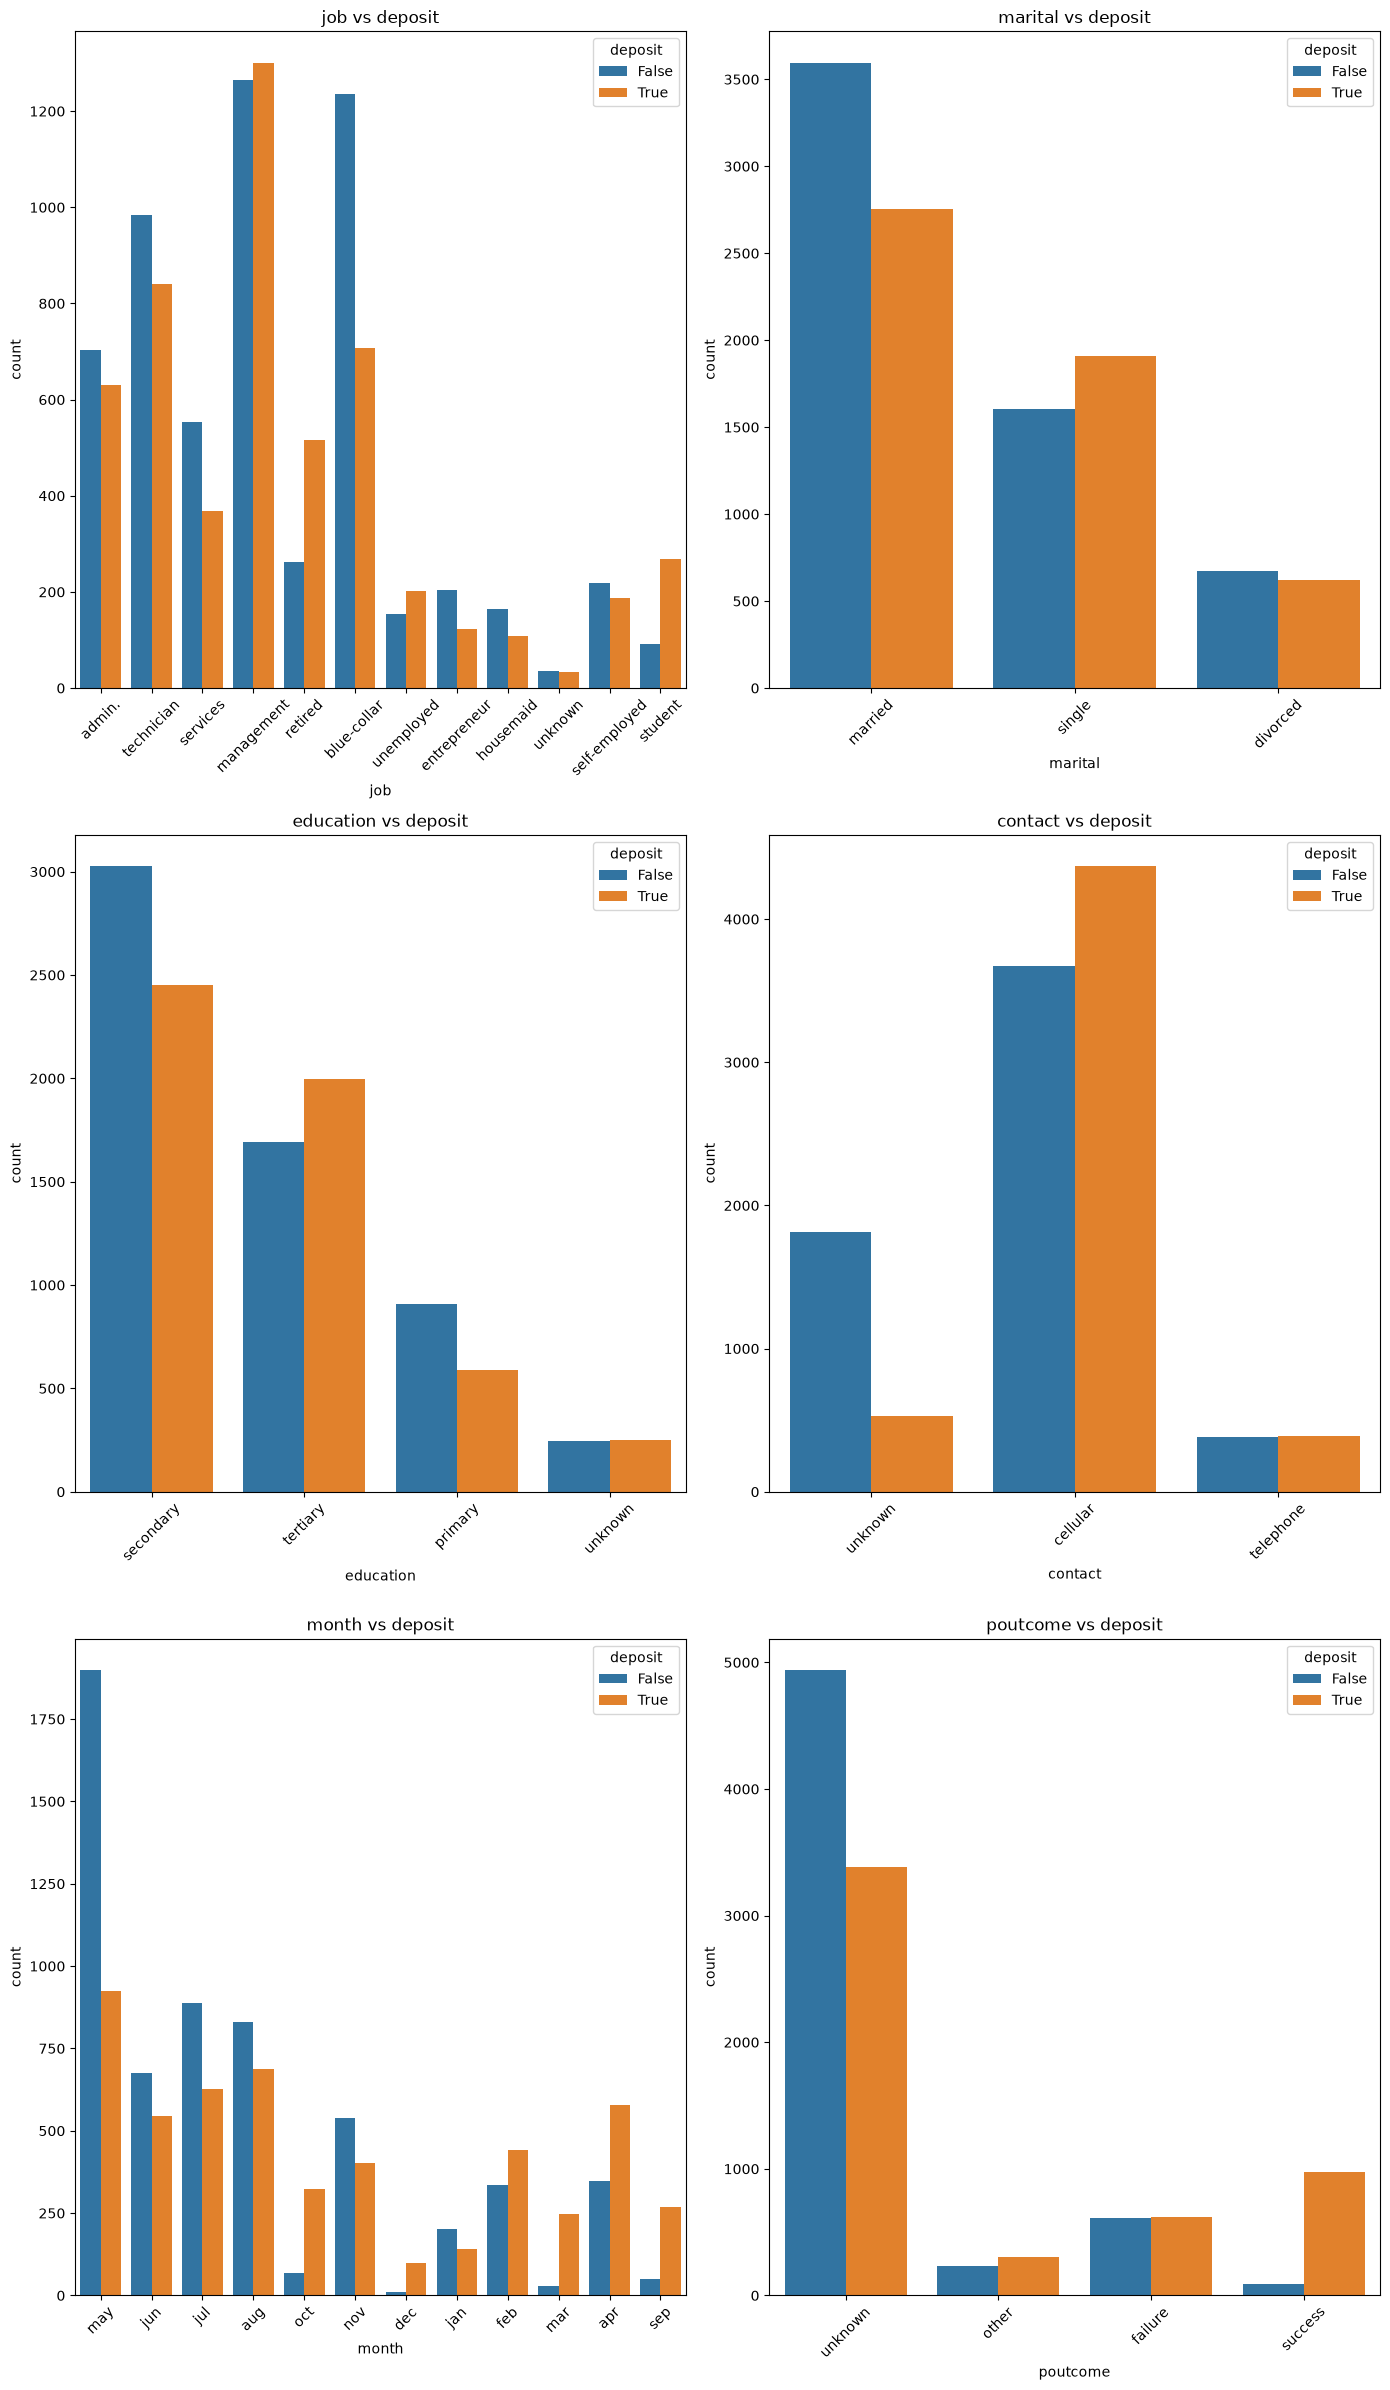

In [20]:
cat_cols = df.select_dtypes(include='object').columns

fig, axes = plt.subplots((len(cat_cols) + 1) // 2, 2, figsize=(14, len(cat_cols) * 4))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(x=col, hue='deposit', data=df, ax=axes[i])
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_title(f'{col} vs deposit')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [21]:
from scipy.stats import chi2_contingency, pointbiserialr

# Para categóricas
for col in df.select_dtypes(include='object').columns:
    tabla = pd.crosstab(df[col], df['deposit'])
    chi2, p, _, _ = chi2_contingency(tabla)
    print(f'{col}: p-valor = {p:.4f}')
print("\n")



job: p-valor = 0.0000
marital: p-valor = 0.0000
education: p-valor = 0.0000
contact: p-valor = 0.0000
month: p-valor = 0.0000
poutcome: p-valor = 0.0000




C:\Users\matin\AppData\Local\Temp\ipykernel_22852\3854868500.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


Ya sabemos que todas las variables categóricas tienen una relación con la variable objetivo que no responde al azar, pero para decidir cuáles incluir en el modelo, es importante revisar la fuerza de esta relación. Para esto usamos Cramér's V, que mide la fuerza de asociación entre dos variables categóricas.

In [22]:
from scipy.stats import chi2_contingency
import numpy as np

def cramers_v(col):
    tabla = pd.crosstab(df[col], df['deposit'])
    chi2, _, _, _ = chi2_contingency(tabla)
    n = tabla.sum().sum()
    return np.sqrt(chi2 / (n * (min(tabla.shape) - 1)))

for col in df.select_dtypes(include='object').columns:
    print(f'{col}: V = {cramers_v(col):.4f}')


job: V = 0.1840
marital: V = 0.0991
education: V = 0.1049
contact: V = 0.2569
month: V = 0.3062
poutcome: V = 0.3000


C:\Users\matin\AppData\Local\Temp\ipykernel_22852\2035937738.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


Parece que las variables `contact`, `month` y `poutcome` tienen una relación más fuerte con la variable objetivo `deposit`, lo que sugiere que podrían ser variables importantes para incluir en el modelo de predicción.

Que raro (al menos para mí) que `job` y `education` no tengan una relación más fuerte con `deposit`.

Hago gráficos de barras para visualizar la relación entre las variables categóricas y la variable objetivo `deposit`. Esto me ayuda a entender mejor cómo se distribuyen los clientes que realizaron un depósito y los que no, en función de estas variables.

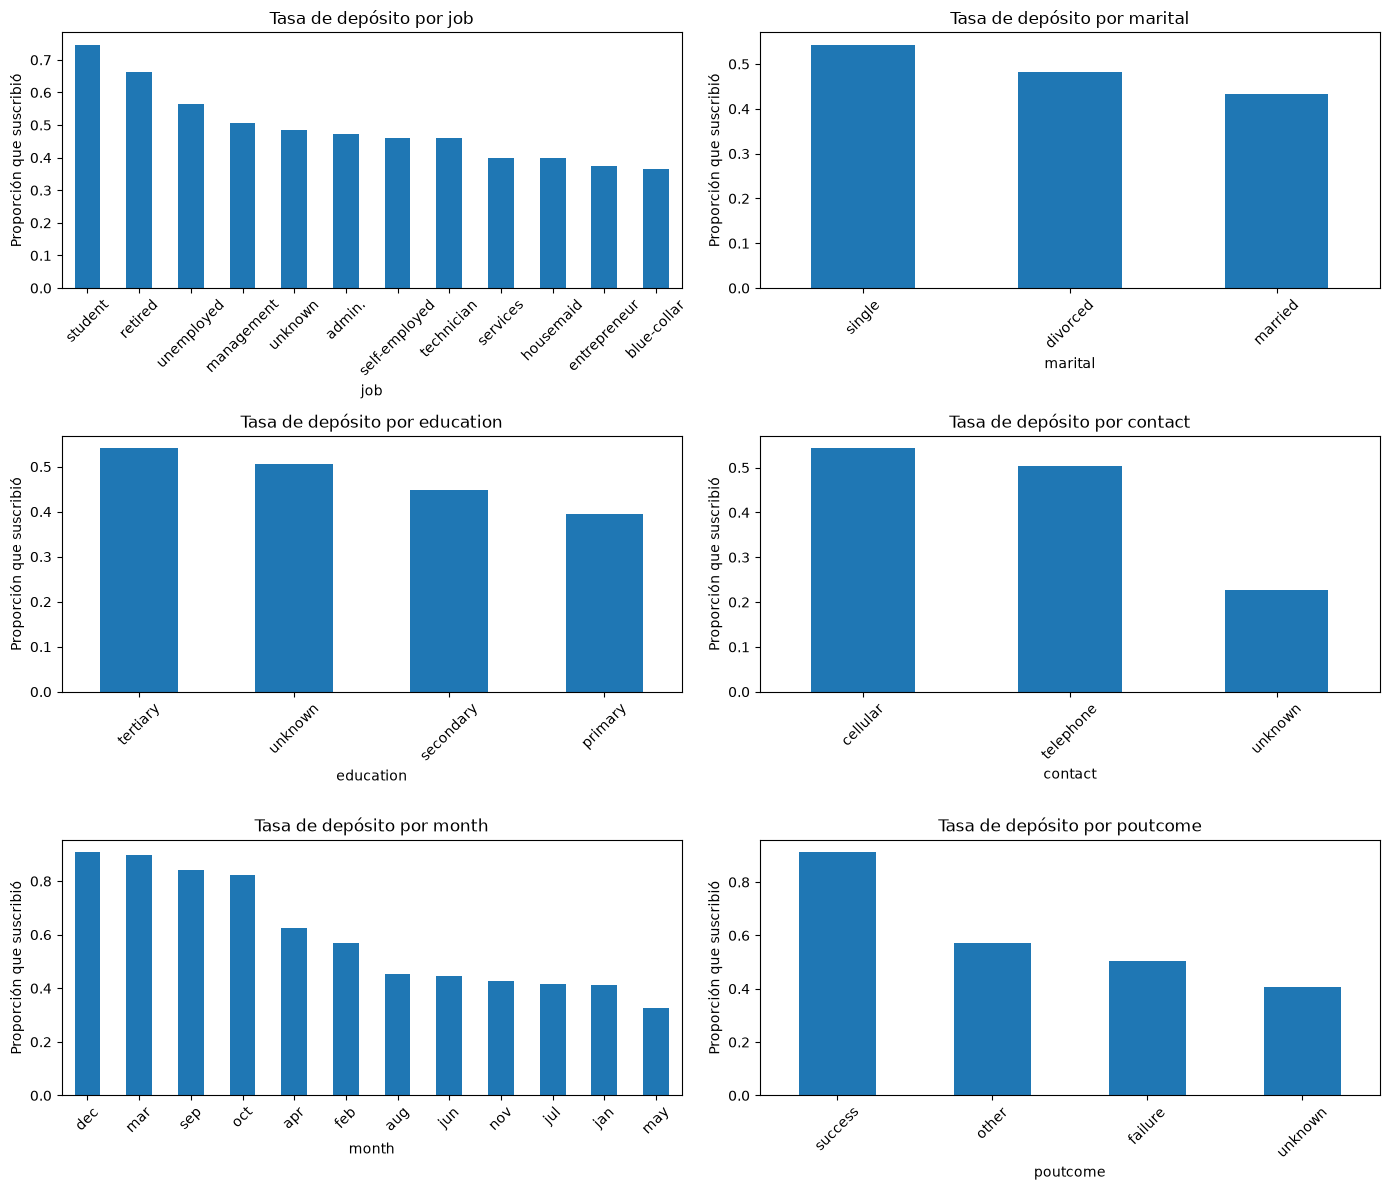

In [23]:
n_cols = 2
n_rows = (len(cat_cols) + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    tasa = df.groupby(col)['deposit'].mean().sort_values(ascending=False)
    tasa.plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'Tasa de depósito por {col}')
    axes[i].set_ylabel('Proporción que suscribió')
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



Aquí se aclaran unas dudas que tenía:
1. ¿Por qué el impacto de `job` es tan bajo? ¿No se supone que a mejor el trabajo, mayor probabilidad de contratar un depósito a plazo fijo debido a la estabilidad económica y la información sobre el sistema financiero?
>Parece que sí pero los registros se ven arrastrados hacia los estudiantes. ¿Por que será? seguramente haya algun factor que ignoro debido a mi falta de conocimiento del negocio, pero es interesante ver que los estudiantes tienen una probabilidad de contratar un depósito a plazo fijo mayor que los demás.
2. ¿Por qué el impacto de `education` es tan bajo? ¿No se supone que a mayor educación, mayor probabilidad de contratar un depósito a plazo fijo?
>Parece que no. Todos los piden más o menos en igual medida.

Haré tambien un mapa de calor para revisar las relaciones entre variables.

Text(0.5, 1.0, 'Mapa de calor de correlaciones')

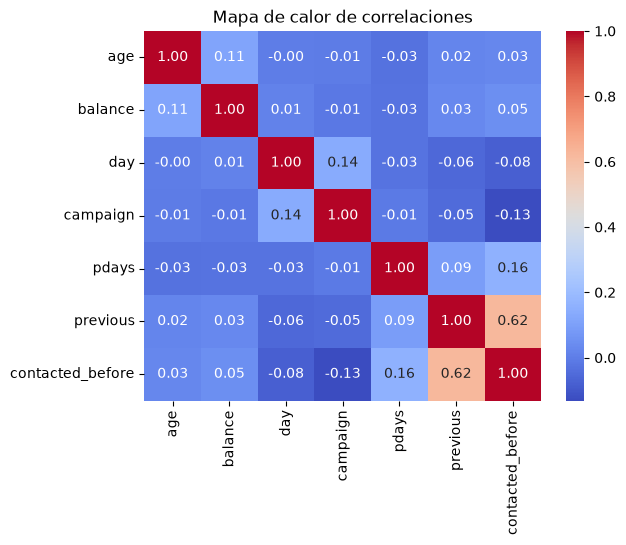

In [24]:
corr = df.select_dtypes(include='number').drop(columns='duration').corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Mapa de calor de correlaciones')

Hay muchos valores cercanos a 0. Esto significa que las variables numéricas son más o menos independientes entre sí, lo que es bueno para el análisis posterior. `contacted_before` y `previous` tienen una correlación muy alta. Esto es esperable debido a que `contacted_before` se creó a partir de `pdays` y tanto `pdays` como `previous` capturan la idea de contacto previo. Debido a que planeo usar varios modelos de machine learning eliminaré `contacted_before` para evitar problemas de multicolinealidad.

# Entonces ¿Qué variables deberían incluirse en el modelo?

Tengo las siguientes variables:
<br>Numéricas:
1. `age` 👍
2. `balance` 👍
3. `day` 🚫
4. `duration` 🚫
5. `pdays` 👍
6. `previous` 👍
7. `contacted_before` 🚫
8. `campaign` 👍

<br>Categóricas:
1. `month` 👍
2. `job` 👍
3. `marital` 🚫
4. `education` 🚫
5. `contact` 👍
6. `poutcome` 👍

<br>Binarias:
1. `default` 🚫
2. `housing` 👍
3. `loan` 🚫

1. `Duration ` NO debe incluirse por las razones mencionadas anteriormente. (Data leakage)
2. `Age` sí debe incluirse. Aunque el análisis bivariado no es concluyente, la edad es una variable que suele tener relación con el comportamiento financiero de las personas, y podría aportar información valiosa al modelo. (Este análisis es derivado de la contradicción en el p-valor y conocimiento de dominio)
3. `balance`, `pdays` y `previous` se incluirán. Tuvieron p-valor ≈ 0 en Mann-Whitney y valores de MI de 0.046, 0.051 y 0.021 respectivamente — entre los más altos de las variables numéricas. pdays además fue tratado previamente para eliminar el valor centinela -1.
4. `contacted_before` se excluye a pesar de haber sido creada para resolver el problema del -1 en pdays. El mapa de calor mostró una correlación de 0.62 con previous, lo que indica redundancia: previous = 0 ya implica que el cliente no fue contactado antes. Incluir ambas agregaría ruido sin información nueva al modelo.
5. Las variables categóricas `poutcome`, `month` y `contact` se incluirán. Tienen los valores de Cramér's V más altos y sus MI son consistentemente altos. `poutcome` es la variable más predictiva de todo el dataset (MI = 0.058): un cliente que ya suscribió en una campaña anterior tiene una probabilidad muy superior de volver a hacerlo.
6. `job` se incluye a pesar de su Cramér's V relativamente bajo. Los gráficos de tasa de conversión mostraron diferencias claras entre categorías, especialmente los estudiantes, que presentan una tasa de depósito notablemente más alta que el resto. El chi-cuadrado confirma que esta diferencia no es producto del azar.
7. `marital` y `education` se excluyen. Ambas tienen MI muy bajo (0.003 y 0.012) y Cramér's V bajo. En los gráficos de tasa de conversión no se observaron diferencias relevantes entre categorías: todos los niveles de educación y estado civil suscribieron en proporciones similares.
Las variables binarias `default` y `loan` se excluyen. `default` tiene MI ≈ 0 y casi todos los registros son False, por lo que no aporta varianza útil al modelo. `loan` tiene MI = 0.000016, esencialmente cero. `housing` se incluye — su MI (0.018) es bajo pero el test de Mann-Whitney fue significativo y los gráficos muestran una diferencia visible en las tasas de conversión.
8. `campaign` se incluye más como un argumento de negocio que estadístico. El análisis numérico muestra una relación negativa: "A más contactos en la campaña actual, menor probabilidad de contratar el servicio". Muchas llamadas podrían molestar al cliente y reducir su interés. Como sea, sirve para la predicción que buscamos.


Entreno un Random Forest con todas las variables (excepto `duration`) para ver si el modelo respalda las decisiones tomadas en el EDA. Las barras **azules** son variables que decidí incluir; las **rojas**, las que excluí.

C:\Users\matin\AppData\Local\Temp\ipykernel_22852\314965098.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_vars = df[features].select_dtypes(include='object').columns.tolist()


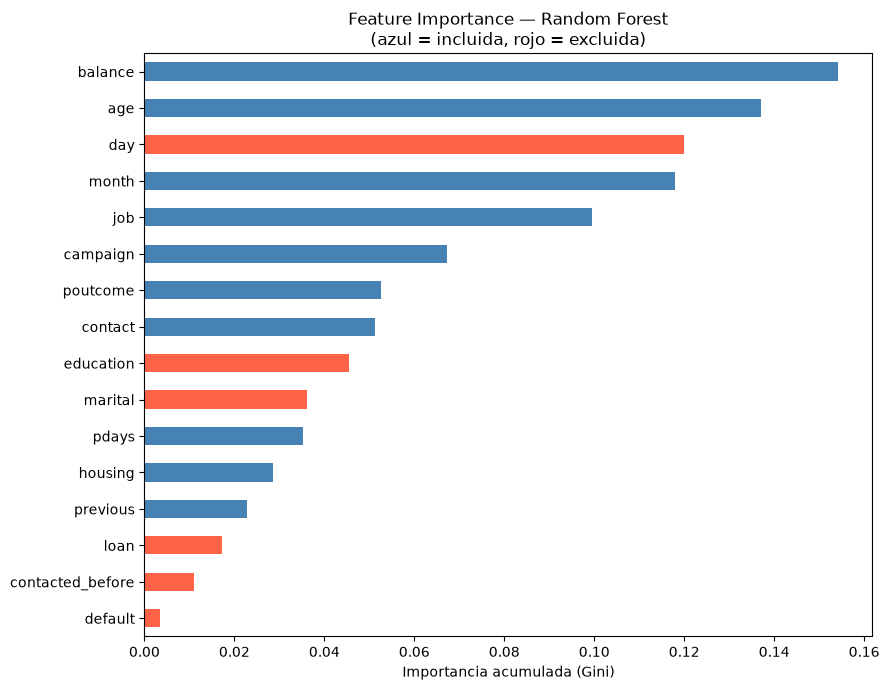

balance             0.154108
age                 0.137177
day                 0.119947
month               0.117896
job                 0.099577
campaign            0.067330
poutcome            0.052556
contact             0.051370
education           0.045487
marital             0.036123
pdays               0.035257
housing             0.028544
previous            0.022860
loan                0.017159
contacted_before    0.011098
default             0.003509


In [25]:
from sklearn.ensemble import RandomForestClassifier

# Todas las variables excepto duration (data leakage)
features = [c for c in df.columns if c not in ['deposit', 'duration']]
cat_vars = df[features].select_dtypes(include='object').columns.tolist()

X_rf = pd.get_dummies(df[features], columns=cat_vars, drop_first=False)
y_rf = df['deposit'].astype(int)

rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_rf, y_rf)

# Agrupa importancias OHE por variable original
def orig_var(col, cats):
    for c in cats:
        if col == c or col.startswith(c + '_'):
            return c
    return col

imp = pd.Series(rf.feature_importances_, index=X_rf.columns)
imp.index = [orig_var(c, cat_vars) for c in imp.index]
imp_grouped = imp.groupby(imp.index).sum().sort_values(ascending=False)

# Marcar variables seleccionadas vs excluidas
seleccionadas = {'age', 'balance', 'pdays', 'previous', 'campaign',
                 'month', 'job', 'contact', 'poutcome', 'housing'}
orden = imp_grouped.sort_values()
colores = ['steelblue' if v in seleccionadas else 'tomato' for v in orden.index]

fig, ax = plt.subplots(figsize=(9, 7))
orden.plot(kind='barh', ax=ax, color=colores)
ax.set_title('Feature Importance — Random Forest\n(azul = incluida, rojo = excluida)')
ax.set_xlabel('Importancia acumulada (Gini)')
plt.tight_layout()
plt.show()

print(imp_grouped.to_string())


En general se ve bien (acorde al análisis que tenía antes). Puede que `day` esté tan alta debido a que RF hace cortes con las distintas variables para ver cual de ellas separa mejor los datos. Como `day` tiene valores entre 1 y 31, RF tiene muchas oportunidades de encontrar cortes y eso podría hacer que, en el análisis, le de importancia a `day` para discriminar y predecir `deposit` — aunque, como vimos antes, la relación entre `day` y `deposit` no es tan clara ni fuerte.

Para confirmar eso usaré Permutation Importance sobre el mismo RF para ver si `day` sigue apareciendo como una variable importante o si su importancia disminuye al eliminar la posibilidad de hacer cortes específicos en esa variable.

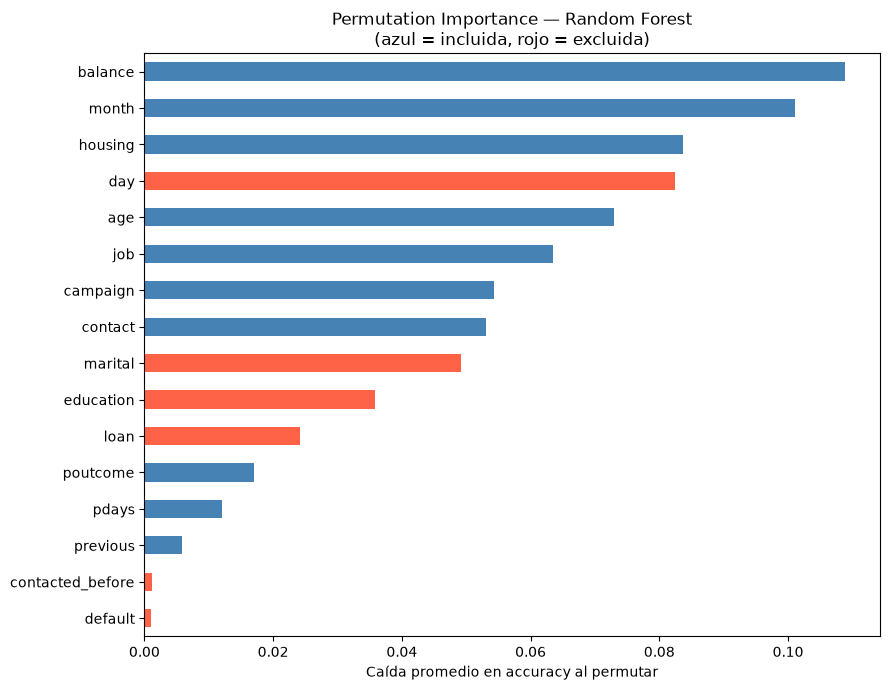

balance             0.108843
month               0.101102
housing             0.083605
day                 0.082494
age                 0.072899
job                 0.063438
campaign            0.054273
contact             0.053001
marital             0.049238
education           0.035755
loan                0.024100
poutcome            0.016950
pdays               0.012014
previous            0.005877
contacted_before    0.001174
default             0.000950


In [26]:
from sklearn.inspection import permutation_importance

result = permutation_importance(rf, X_rf, y_rf, n_repeats=10, random_state=42, n_jobs=-1)

# Agrupa por variable original (reutiliza orig_var y cat_vars de la celda anterior)
imp_perm = pd.Series(result.importances_mean, index=X_rf.columns)
imp_perm.index = [orig_var(c, cat_vars) for c in imp_perm.index]
imp_perm_grouped = imp_perm.groupby(imp_perm.index).sum().sort_values(ascending=False)

orden_perm = imp_perm_grouped.sort_values()
colores_perm = ['steelblue' if v in seleccionadas else 'tomato' for v in orden_perm.index]

fig, ax = plt.subplots(figsize=(9, 7))
orden_perm.plot(kind='barh', ax=ax, color=colores_perm)
ax.set_title('Permutation Importance — Random Forest\n(azul = incluida, rojo = excluida)')
ax.set_xlabel('Caída promedio en accuracy al permutar')
plt.tight_layout()
plt.show()

print(imp_perm_grouped.to_string())


Comparo un árbol de decisión con y sin `day` usando 5-fold cross-validation estratificado. Si la diferencia en accuracy y AUC es mínima, `day` no aporta señal que generalice.

          Sin day  Con day
Accuracy   0.6335   0.6306
AUC-ROC    0.6325   0.6303

Diferencia Accuracy : -0.0029
Diferencia AUC-ROC  : -0.0022


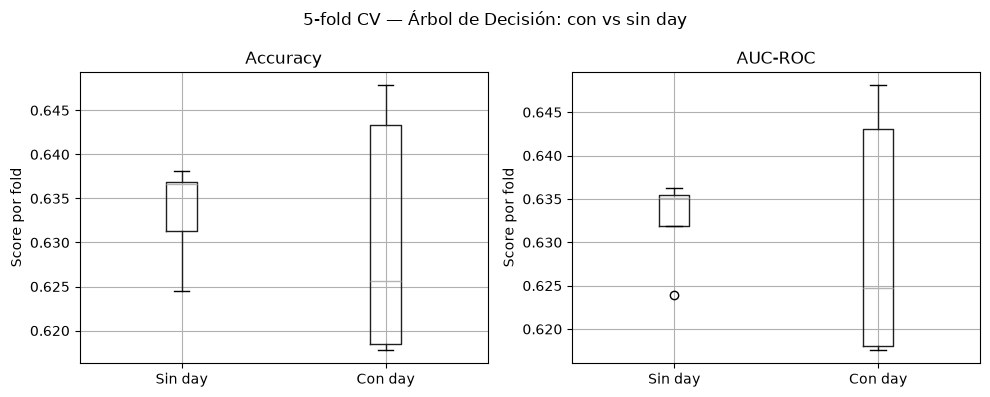

In [27]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold

features_base = ['age', 'balance', 'pdays', 'previous', 'campaign',
                 'month', 'job', 'contact', 'poutcome', 'housing']
cat_features  = ['month', 'job', 'contact', 'poutcome']

y_cv   = df['deposit'].astype(int)
X_sin  = pd.get_dummies(df[features_base],           columns=cat_features, drop_first=False)
X_con  = pd.get_dummies(df[features_base + ['day']], columns=cat_features, drop_first=False)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
dt = DecisionTreeClassifier(random_state=42)

s_sin = cross_validate(dt, X_sin, y_cv, cv=cv, scoring=['accuracy', 'roc_auc'])
s_con = cross_validate(dt, X_con, y_cv, cv=cv, scoring=['accuracy', 'roc_auc'])

# Tabla resumen
resumen = pd.DataFrame({
    'Sin day': [s_sin['test_accuracy'].mean(), s_sin['test_roc_auc'].mean()],
    'Con day': [s_con['test_accuracy'].mean(), s_con['test_roc_auc'].mean()],
}, index=['Accuracy', 'AUC-ROC']).round(4)
print(resumen)
print(f"\nDiferencia Accuracy : {s_con['test_accuracy'].mean() - s_sin['test_accuracy'].mean():+.4f}")
print(f"Diferencia AUC-ROC  : {s_con['test_roc_auc'].mean()  - s_sin['test_roc_auc'].mean():+.4f}")

# Boxplots por fold
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, label, key in zip(axes, ['Accuracy', 'AUC-ROC'], ['accuracy', 'roc_auc']):
    pd.DataFrame({
        'Sin day': s_sin[f'test_{key}'],
        'Con day': s_con[f'test_{key}']
    }).boxplot(ax=ax)
    ax.set_title(label)
    ax.set_ylabel('Score por fold')

plt.suptitle('5-fold CV — Árbol de Decisión: con vs sin day')
plt.tight_layout()
plt.show()


1. Sin day: mediana más alta (0.636) y caja muy estrecha — el modelo es consistente entre folds.

2. Con day: mediana más baja (0.625) y caja mucho más ancha. el modelo es inestable, rinde mejor en algunos folds y peor en otros.

>La decisión de sacar `day` es correcta

Mismo análisis para las otras variables excluidas: `marital`, `education` y `loan`.
Comparo que pasa con la prediccion en 2 casos: con todas las variables seleccionadas en el EDA (baseline) contra agregar cada variable de a una.

             Accuracy  AUC-ROC  Δ Accuracy  Δ AUC-ROC
Variable                                             
Baseline       0.6335   0.6325      0.0000     0.0000
+ marital      0.6354   0.6348      0.0019     0.0023
+ education    0.6359   0.6350      0.0024     0.0025
+ loan         0.6274   0.6269     -0.0061    -0.0056


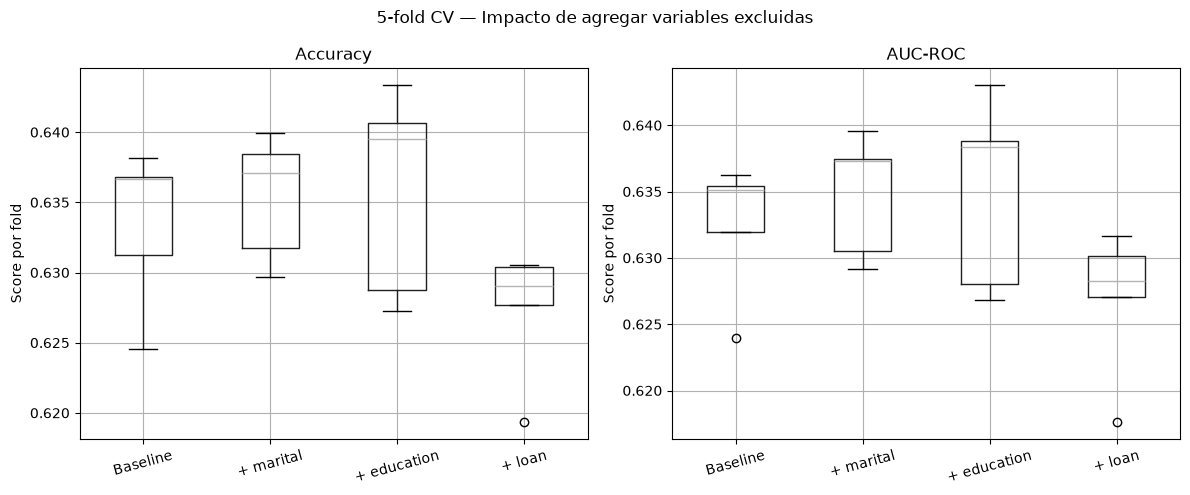

In [28]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold

features_base = ['age', 'balance', 'pdays', 'previous', 'campaign',
                 'month', 'job', 'contact', 'poutcome', 'housing']
cat_features  = ['month', 'job', 'contact', 'poutcome']
vars_test     = ['marital', 'education', 'loan']

y_cv   = df['deposit'].astype(int)
X_base = pd.get_dummies(df[features_base], columns=cat_features, drop_first=False)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
dt = DecisionTreeClassifier(random_state=42)

s_base = cross_validate(dt, X_base, y_cv, cv=cv, scoring=['accuracy', 'roc_auc'])
scores_all = {'Baseline': s_base}

filas = [{'Variable': 'Baseline',
          'Accuracy': s_base['test_accuracy'].mean(),
          'AUC-ROC':  s_base['test_roc_auc'].mean(),
          'Δ Accuracy': 0.0, 'Δ AUC-ROC': 0.0}]

for var in vars_test:
    # pandas 3+ usa dtype str en vez de object — se chequea con is_string_dtype
    extra_cats = [v for v in cat_features + [var]
                  if pd.api.types.is_object_dtype(df[v]) or pd.api.types.is_string_dtype(df[v])]
    X_ext = pd.get_dummies(df[features_base + [var]], columns=extra_cats, drop_first=False)
    s_ext = cross_validate(dt, X_ext, y_cv, cv=cv, scoring=['accuracy', 'roc_auc'])
    scores_all[f'+ {var}'] = s_ext
    filas.append({
        'Variable':   f'+ {var}',
        'Accuracy':   s_ext['test_accuracy'].mean(),
        'AUC-ROC':    s_ext['test_roc_auc'].mean(),
        'Δ Accuracy': s_ext['test_accuracy'].mean() - s_base['test_accuracy'].mean(),
        'Δ AUC-ROC':  s_ext['test_roc_auc'].mean()  - s_base['test_roc_auc'].mean(),
    })

resumen = pd.DataFrame(filas).set_index('Variable').round(4)
print(resumen)

# Boxplots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, label, key in zip(axes, ['Accuracy', 'AUC-ROC'], ['accuracy', 'roc_auc']):
    pd.DataFrame({k: v[f'test_{key}'] for k, v in scores_all.items()}).boxplot(ax=ax)
    ax.set_title(label)
    ax.set_ylabel('Score por fold')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('5-fold CV — Impacto de agregar variables excluidas')
plt.tight_layout()
plt.show()


1. `marital`: agregarla no mejora el modelo. la caja se hace mas ancha (mas variabilidad entre folds) y, en general, se parece bastante con la baseline. Esto confirma que `marital` no aporta información relevante para predecir `deposit`.
2. `education`: agregarla tampoco mejora el modelo. La caja se ensancha mucho.
3. `loan`: la caja está mucho mas baja que baseline, lo que confirma que `loan` no aporta información útil para predecir `deposit` y que su inclusión empeora el rendimiento del modelo. Esto es consistente con el análisis de MI, donde `loan` tenía un valor prácticamente cero.

## Sobre los `Unknown`
Las variables que contienen el tipo de dato `Unknown` lo tienen porque aporta información. No son datos faltantes ni errores en el registro. Por eso mismo los dejaré como están. No hace falta hacerles cambios tratandolos como errores o valores a corregir. Además, dado que eliminé `education` y `marital`, las categorías `Unknown` de esas variables ya no existen, por lo que no hay que preocuparse por ellas. En el caso de `job`, la categoría `Unknown` se mantiene porque podría representar un grupo específico de clientes cuya ocupación no está registrada, y esa falta de información en sí misma podría ser relevante para predecir `deposit`.

# Parte 2 — Entrenamiento de modelos

## Preprocesamiento

Antes de entrenar los modelos preparo los datos en tres pasos:

1. Separar las variables predictoras de la variable objetivo (X e y)
2. Aplico one hot encoding a las variables categóricas seleccionadas (en cat_features). Esto debido a que los modelos trabajan mejor con números que con texto. OHE crea muchas columnas de valores binarios para cada categoría. Es preferible esto a asignarles números a esas categorías y que se creen jerarquías que no existen.
3. Dividir en set de entrenamiento (80%) y set de prueba (20%)


In [29]:
from sklearn.model_selection import train_test_split

features_sel = ['age', 'balance', 'pdays', 'previous', 'campaign',
                'month', 'job', 'contact', 'poutcome', 'housing']
cat_features  = ['month', 'job', 'contact', 'poutcome']

X = pd.get_dummies(df[features_sel], columns=cat_features, drop_first=False)
y = df['deposit'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"Dist. train — 0: {(y_train==0).sum()}  1: {(y_train==1).sum()}  "
      f"({y_train.value_counts(normalize=True).round(3).to_dict()})")
print(f"Dist. test  — 0: {(y_test==0).sum()}  1: {(y_test==1).sum()}  "
      f"({y_test.value_counts(normalize=True).round(3).to_dict()})")

X_train: (8929, 37)  |  X_test: (2233, 37)
Dist. train — 0: 4698  1: 4231  ({0: 0.526, 1: 0.474})
Dist. test  — 0: 1175  1: 1058  ({0: 0.526, 1: 0.474})


### Justificación de las decisiones de preprocesamiento

| Decisión | Justificación |
|---|---|
| Split 80/20 | El dataset es suficientemente grande para soportar esta partición. Además de ser bastante estandar en la ciencia de datos |
| stratify | Preserva la proporción de clases. si no se usa, por azar el split podría quedar desbalanceado |
| OHE | Lo exige sklearn |
| Sin escalado | DecisionTree y RandomForest son modelos basados en cortes de umbral, completamente insensibles a la magnitud de las variables |


# Hiperparámetros
Para definir algunos hiperparámetros utilicé K FOLD (5) en las variables `cv` (cross validation). Esto sobretodo para asegurar que el modelo no dependa de mis conocimientos o experiencia previa. Así siempre se usan los mejores hiperparámetros. Además el data set no es taaaan grande como para preocuparme por la demora de computo.

## Modelo 1 — Árbol de Decisión

### Hiperparámetros

| Hiperparámetro | Valor | Justificación |
|---|---|---|
| `max_depth` | determinado por CV | Se probaron valores del 1 al 10 con 5-fold cross-validation sobre el set de entrenamiento. El valor con mejor CV mean accuracy es el que se usa|
| `min_samples_leaf` | 15 | Evita que una hoja se forme con muy pocos ejemplos |
| `random_state` | 42 | Reproducibilidad |

max_depth= 1 | CV mean: 0.6058 ± 0.0037
max_depth= 2 | CV mean: 0.6058 ± 0.0037
max_depth= 3 | CV mean: 0.6465 ± 0.0111
max_depth= 4 | CV mean: 0.6573 ± 0.0083
max_depth= 5 | CV mean: 0.6719 ± 0.0082
max_depth= 6 | CV mean: 0.6825 ± 0.0114
max_depth= 7 | CV mean: 0.6859 ± 0.0111
max_depth= 8 | CV mean: 0.6904 ± 0.0119
max_depth= 9 | CV mean: 0.6920 ± 0.0143
max_depth=10 | CV mean: 0.6959 ± 0.0133


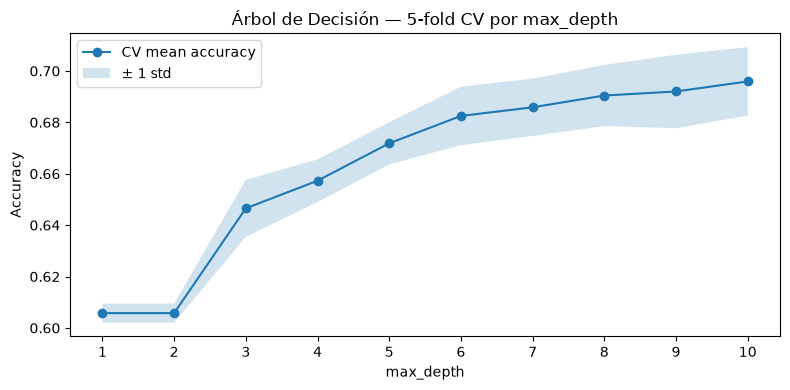


Mejor max_depth (CV): 10 (CV mean: 0.6959)
Profundidad del árbol : 10
Número de hojas       : 146
Train accuracy        : 0.7287
Test accuracy         : 0.7058


In [30]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
depth_range = range(1, 11)
cv_means, cv_stds = [], []

for d in depth_range:
    dt = DecisionTreeClassifier(max_depth=d, min_samples_leaf=15, random_state=42)
    scores = cross_val_score(dt, X_train, y_train, cv=cv, scoring='accuracy')
    cv_means.append(scores.mean())
    cv_stds.append(scores.std())
    print(f"max_depth={d:2d} | CV mean: {scores.mean():.4f} ± {scores.std():.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(depth_range), cv_means, marker='o', label='CV mean accuracy')
ax.fill_between(list(depth_range),
                [m - s for m, s in zip(cv_means, cv_stds)],
                [m + s for m, s in zip(cv_means, cv_stds)],
                alpha=0.2, label='± 1 std')
ax.set_xlabel('max_depth')
ax.set_ylabel('Accuracy')
ax.set_title('Árbol de Decisión — 5-fold CV por max_depth')
ax.set_xticks(list(depth_range))
ax.legend()
plt.tight_layout()
plt.show()

best_depth = list(depth_range)[cv_means.index(max(cv_means))]
print(f"\nMejor max_depth (CV): {best_depth} (CV mean: {max(cv_means):.4f})")

dt_model = DecisionTreeClassifier(max_depth=best_depth, min_samples_leaf=15, random_state=42)
dt_model.fit(X_train, y_train)
print(f"Profundidad del árbol : {dt_model.get_depth()}")
print(f"Número de hojas       : {dt_model.get_n_leaves()}")
print(f"Train accuracy        : {dt_model.score(X_train, y_train):.4f}")
print(f"Test accuracy         : {dt_model.score(X_test, y_test):.4f}")

## Modelo 2 — Random Forest

En este dataset tengo algunas consideraciones a tomar en cuenta para decidirme por este modelo:
1. Hay muchos outliers (mostrados en los boxplots) que podrían arrastrar los cálculos de distancias en modelos como KNN, SVM, etc.
2. Existen relaciones no lineales que modelos como regresión lineal, logística o (de nuevo SVM) no procesarían bien sin unos pasos previos de normalización, trato de outliers, etc.
<br><br>En honor al tiempo usaré Random Forest, que maneja bien estas situaciones sin necesidad de preprocesamiento adicional.
<br><br>Para elegir el mejor `n_estimators` usaré 5-fold cross-validation sobre el set de entrenamiento, igual que con el árbol de decisión — así el test set queda reservado solo para la evaluación final.

### Hiperparámetros

| Hiperparámetro | Valor | Justificación |
|---|---|---|
| `n_estimators` | determinado por CV | Se probaron 100, 120, 160 y 200 con 5-fold CV. El que da mejor CV mean accuracy es el elegido |
| `max_depth` | 8 | Limita la profundidad de los árboles para evitar sobreajuste |
| `min_samples_leaf` | 10 | Mínimo por hoja, más relajado que en el DT individual porque el ensemble (todos los arboles juntos) compensa la varianza de cada árbol |
| `random_state` | 42 | Reproducibilidad |
| `n_jobs` | -1 | Usa todos los núcleos disponibles del procesador |

n_estimators=100 | CV mean: 0.7214 ± 0.0089
n_estimators=120 | CV mean: 0.7230 ± 0.0096
n_estimators=160 | CV mean: 0.7223 ± 0.0085
n_estimators=200 | CV mean: 0.7219 ± 0.0085


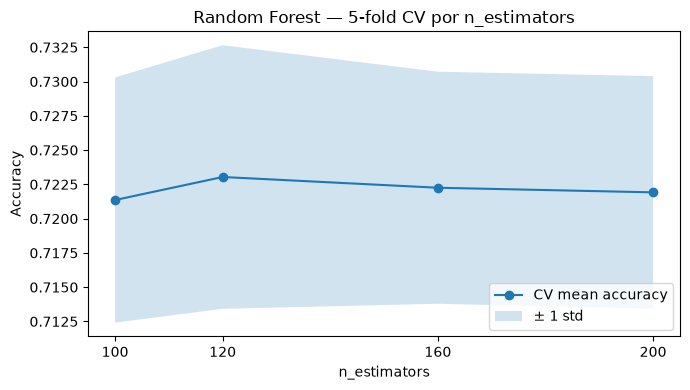


Mejor n_estimators (CV): 120 (CV mean: 0.7230)
Train accuracy : 0.7323
Test accuracy  : 0.7241


In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

df_rf = pd.read_csv('bank.csv')
binary_cols = ['default', 'housing', 'loan', 'deposit']
df_rf[binary_cols] = df_rf[binary_cols].apply(lambda col: col.map({'yes': 1, 'no': 0})).astype(bool)
median_pdays = df_rf.loc[df_rf['pdays'] != -1, 'pdays'].median()
df_rf['pdays'] = df_rf['pdays'].replace(-1, median_pdays)

features_sel = ['age', 'balance', 'pdays', 'previous', 'campaign',
                'month', 'job', 'contact', 'poutcome', 'housing']
cat_features  = ['month', 'job', 'contact', 'poutcome']
X = pd.get_dummies(df_rf[features_sel], columns=cat_features, drop_first=False)
y = df_rf['deposit'].astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
n_list = [100, 120, 160, 200]
cv_means, cv_stds = [], []

for n in n_list:
    rf = RandomForestClassifier(n_estimators=n, max_depth=8, min_samples_leaf=10,
                                random_state=42, n_jobs=-1)
    scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring='accuracy')
    cv_means.append(scores.mean())
    cv_stds.append(scores.std())
    print(f"n_estimators={n:3d} | CV mean: {scores.mean():.4f} ± {scores.std():.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(n_list, cv_means, marker='o', label='CV mean accuracy')
ax.fill_between(n_list,
                [m - s for m, s in zip(cv_means, cv_stds)],
                [m + s for m, s in zip(cv_means, cv_stds)],
                alpha=0.2, label='± 1 std')
ax.set_xlabel('n_estimators')
ax.set_ylabel('Accuracy')
ax.set_title('Random Forest — 5-fold CV por n_estimators')
ax.set_xticks(n_list)
ax.legend()
plt.tight_layout()
plt.show()

best_n = n_list[cv_means.index(max(cv_means))]
print(f"\nMejor n_estimators (CV): {best_n} (CV mean: {max(cv_means):.4f})")

rf_model = RandomForestClassifier(n_estimators=best_n, max_depth=8, min_samples_leaf=10,
                                   random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print(f"Train accuracy : {rf_model.score(X_train, y_train):.4f}")
print(f"Test accuracy  : {rf_model.score(X_test, y_test):.4f}")

>Decidí agregar XGBoost solo por interés personal. Además se ajusta bien a lo que ya llevo hasta ahora y las características del dataset

## Modelo 3 — XGBoost

XGBoost construye árboles de forma secuencial: cada árbol nuevo se enfoca en corregir los errores del anterior. A diferencia de Random Forest, que crea árboles independientes en paralelo, el boosting reduce el sesgo iterativamente.
<br><br>Los hiperparámetros los elegí por ser bien estandar en el data science. Para evaluar el rendimiento de forma robusta igual uso 5-fold

### Hiperparámetros

| Hiperparámetro | Valor | Justificación |
|---|---|---|
| `n_estimators` | 200 | Número de rondas de boosting. Uso la misma base que RF para comparación directa |
| `max_depth` | 4 | Como cada arbol solo tiene que resolver los problemas del arbol anterior no necesita ser tan profundo. Eligo 4 para evitar que cada arbol memorice patrones en vez de generalizaciones. Si lo hicieran, esa memorización se arrastraría a los arboles venideros |
| `learning_rate` | 0.1 | Cuánto aporta cada árbol nuevo. Más bajo = más conservador, necesita más árboles para converger. Eligo 0.1 porque, en el datascience, está demostrado que funciona bien con la combinación de 200 arboles|
| `subsample` | 0.8 | Fracción del dataset usada en cada ronda. Introduce aleatoriedad para evitar sobreajuste |
| `colsample_bytree` | 0.8 | Fracción de columnas usadas por árbol — similar al `max_features` de RF |
| `random_state` | 42 | Reproducibilidad |

In [32]:
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

cv_scores = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring='accuracy')
xgb_model.fit(X_train, y_train)

print(f"CV mean accuracy : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Train accuracy   : {xgb_model.score(X_train, y_train):.4f}")
print(f"Test accuracy    : {xgb_model.score(X_test, y_test):.4f}")

CV mean accuracy : 0.7221 ± 0.0052
Train accuracy   : 0.7639
Test accuracy    : 0.7331


# Parte 3 — Evaluación de modelos

Es importante destacar que puedo comparar directamente los 3 modelos debido a que los 3 comparten los mismo hiperparámetros de selección de datos. Mismos X_test, y_test, random_states y todos comparten el stratify=y.
Todos los modelos usan los mismos datos para entrenarse y evaluarse.

Para comparar los tres modelos uso las siguientes métricas:

| Métrica | Qué mide |
|---|---|
| **Accuracy** | Proporción de predicciones correctas en total |
| **Precision** | De los que predije como "suscribe", ¿cuántos realmente suscribieron? |
| **Recall** | De los que realmente suscribieron, ¿cuántos detecté correctamente? |
| **F1** | Media armónica entre Precision y Recall — útil cuando ambas importan |
| **ROC-AUC** | Qué tan bien separa el modelo las dos clases a lo largo de todos los umbrales posibles |

La métrica más relevante para este problema de negocio es el **Recall**: no detectar a un cliente que sí iba a suscribir (falso negativo) implica perder ese ingreso. Llamar de más a alguien que no iba a suscribir (falso positivo) solo cuesta tiempo de agente y, aunque puede ser molesto para la persona a la que se llama y puede generar peor imagen al banco, es menos grave.

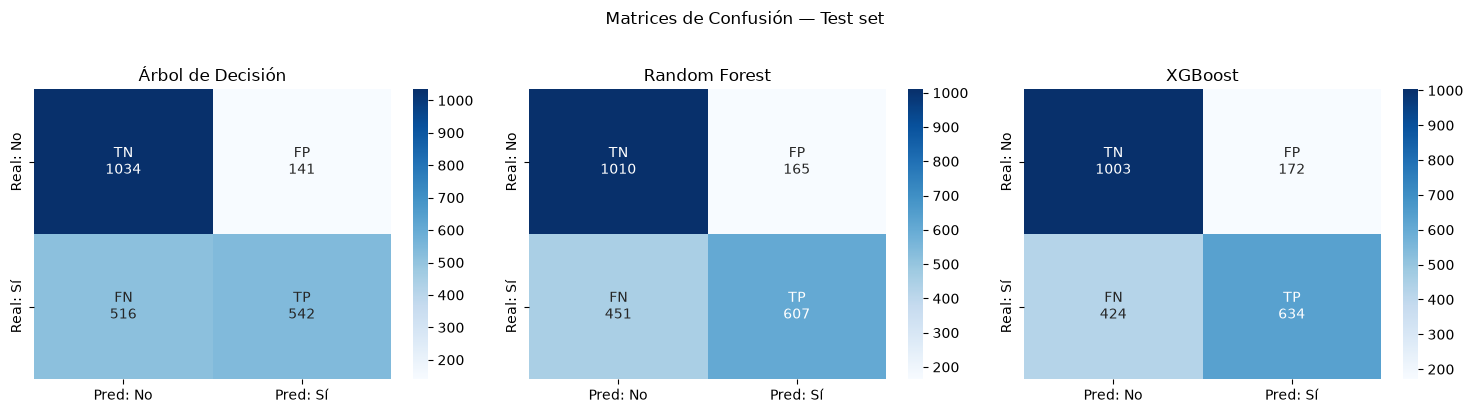

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                              recall_score, f1_score, roc_auc_score, roc_curve)

modelos = {
    'Árbol de Decisión': dt_model,
    'Random Forest':     rf_model,
    'XGBoost':           xgb_model
}

# Matrices de confusión
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (nombre, modelo) in zip(axes, modelos.items()):
    cm = confusion_matrix(y_test, modelo.predict(X_test))
    tn, fp, fn, tp = cm.ravel()
    annot = [[f'TN\n{tn}', f'FP\n{fp}'], [f'FN\n{fn}', f'TP\n{tp}']]
    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', ax=ax,
                xticklabels=['Pred: No', 'Pred: Sí'],
                yticklabels=['Real: No', 'Real: Sí'])
    ax.set_title(nombre)
plt.suptitle('Matrices de Confusión — Test set', y=1.02)
plt.tight_layout()
plt.show()

In [34]:
# Tabla de métricas
filas = []
for nombre, modelo in modelos.items():
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]
    filas.append({
        'Modelo':    nombre,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1':        f1_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_prob),
    })

tabla = pd.DataFrame(filas).set_index('Modelo').round(4)
print(tabla.to_string())

                   Accuracy  Precision  Recall      F1  ROC-AUC
Modelo                                                         
Árbol de Decisión    0.7058     0.7936  0.5123  0.6226   0.7502
Random Forest        0.7241     0.7863  0.5737  0.6634   0.7748
XGBoost              0.7331     0.7866  0.5992  0.6803   0.7806


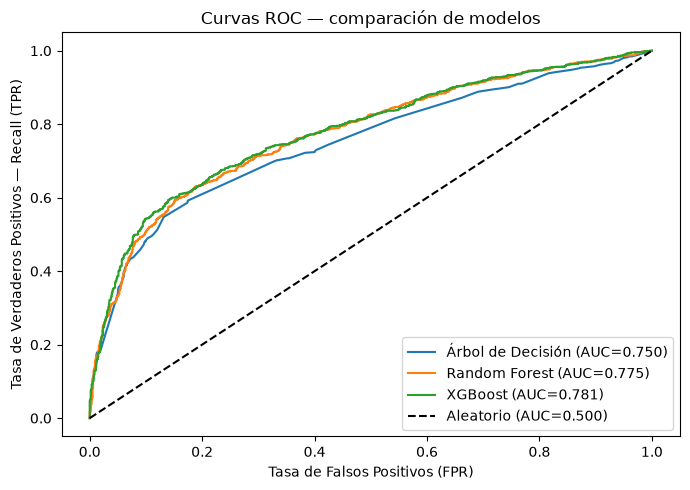

In [35]:
# Curvas ROC
fig, ax = plt.subplots(figsize=(7, 5))
for nombre, modelo in modelos.items():
    y_prob = modelo.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{nombre} (AUC={auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', label='Aleatorio (AUC=0.500)')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos — Recall (TPR)')
ax.set_title('Curvas ROC — comparación de modelos')
ax.legend()
plt.tight_layout()
plt.show()

# ¿Cual es el mejor modelo?

Aquí combino 3.3 con 4.1 ya que son similares en la explicación

### Parte 4 - Análisis de errores y decisión de negocio

No todas las métricas importan igual en este contexto.
<br>Los `falsos negativos` significan que una persona que sí era propensa a contratar el servicio se "escapó" de las manos del banco
<br>Los `falsos positivos` significan que se pierde tiempo tratando de convencer a una persona poco motivada a contratar el servicio y se daña la imagen del banco en el proceso
<br><br>En el contexto del banco: Es mucho peor un falso negativo. Se pierde dinero en la pérdida de oportunidad de ventas y se destinan mal los recursos humanos.


Por ejemplo: En las métricas de `XGBoost` se muestra que hay 424 falsos negativos. Si cada una de esas personas le significara al banco una pérdida de $100.000 pesos, representa una pérdida de $42.400.000

Otro ejemplo: En las métricas de `XGBoost` se muestra que hay 172 falsos positivos. Si cada una de esas llamadas dura en promedio 7 minutos, significaría que el banco está perdiendo 1204 minutos en llamadas a personas poco propensas a aceptar el servicio. Unas 20 horas de trabajo humano.

En los otros 2 modelos esos datos empeoran la situación del banco (excepto en "arbol de decision" donde los Falsos positivos son ligeramente menores)

>El modelo que mejor minimiza los falsos negativos es `XGBoost`

Además, considerando que podría ser que el banco quiera ordenar qué personas son más propensas que otras a contratar el servicio (y ordenar sus esfuerzos de manera más granular) `XGBoost` es el modelo con el AUC más alto. Es el más capaz para ordenar a los clientes según contratarán o no.

Sobre la interpretabilidad: `XGBoost` es el modelo menos interpretable entre los 3. Sin embargo, para este problema no importa tanto la interpretabilidad. No importa tanto saber por qué un cliente será más propenso a contratar el servicio (al menos no en este contexto específico donde el problema no lo requiere) por eso la "caja negra" que genera `XGBoost` no es tan problemática. Quizas en un entorno real sí le interese al banco saber qué variables específicas influyen en la desisión de la persona. En ese caso se podría considerar un arbol de desición como mejor opción.

Sobre el nivel de computo: `XGBoost` es el modelo más costoso en términos de computación. En este caso el dataset no es tan grande y por eso este factor no es tan importante. Para datasets más grandes valdría considerar Random forest.

#### Las otras métricas

El árbol de decisión es el que tiene la presición mas alta (es el que más aciertos tiene) pero tambien tiene un bajo recall en comparación con los otros modelos. Acierta pero es muy quisquilloso con sus decisiones. Para un banco la mejor estrategia es no perder clientes asi que el recall debe ser lo más alto posible. `XGBoost` gana.

En todas las demás métricas siempre gana `XGBoost`

## Detalle importante

>Sostengo mi preferencia por `XGBoost` pero tambien reconozco que las diferencias entre los 3 modelos son mas bien pequeñas. Los 3 se comportan bien y, en un entorno real, habría que sopesar el coste computacional y la baja interpretabilidad de `XGBoost`

### 4.2 - 5000 clientes nuevos

#### Pasos

1. Los 5000 nuevos registros deben pasar por el pipeline de procesamiento de datos que está en este notebook. Reemplazar los -1 de pdays con la mediana calculada sobre el set original. Aplicar one hot encoding a las variables categóricas con las mismas columnas que se utilizaron para entrenar los modelos.<br> Si alguno de los clientes trae información nueva (columnas) que no estaban consideradas en el dataset de entrenamiento, esa información tampoco se considerará para el modelo.
2. XGBoost nos dará la probabilidad de que el cliente acepte o no el servicio. Los datos se ordenan de mayor a menor.<br>Debido a ese ordenamiento el banco será capaz de asignar los recursos de mejor manera.
3. Se toman los 800 (o 'x') mejores valores. Este número está decidido por el banco donde esos x representarán los clientes que vale la pena llamar debido a su probabilidad de aceptar el servicio.

Hago una simulación: trato X_test (2.233 filas) como si fueran clientes nuevos y selecciono los top 800 por probabilidad de suscripción

In [36]:
probas = xgb_model.predict_proba(X_test)[:, 1]
ranking = pd.DataFrame({
    'cliente_id': X_test.index,
    'probabilidad': probas,
    'suscribio_real': y_test.values
}).sort_values('probabilidad', ascending=False).reset_index(drop=True)

top_800 = ranking.head(800)

# Métricas de comparación
tasa_top800   = top_800['suscribio_real'].mean()
tasa_base     = y_test.mean()
suscriptores_capturados = top_800['suscribio_real'].sum()
suscriptores_totales    = y_test.sum()

print("=" * 60)
print("RANKING — Top 10 clientes con mayor probabilidad")
print("=" * 60)
print(ranking.head(10).to_string(index=False))

print("\n" + "=" * 60)
print("RESULTADOS DEL TOP 800")
print("=" * 60)
print(f"Tasa de conversión en el top 800   : {tasa_top800:.2%}")
print(f"Tasa de conversión base (test set) : {tasa_base:.2%}")
print(f"Lift sobre selección aleatoria     : {tasa_top800/tasa_base:.2f}x")
print(f"\nSuscriptores capturados en el top 800 : {suscriptores_capturados} de {suscriptores_totales}")
print(f"% de suscriptores reales capturados   : {suscriptores_capturados/suscriptores_totales:.1%}")
print(f"\nProbabilidad mínima dentro del top 800 : {top_800['probabilidad'].min():.4f}")
print(f"Probabilidad máxima dentro del top 800 : {top_800['probabilidad'].max():.4f}")


RANKING — Top 10 clientes con mayor probabilidad
 cliente_id  probabilidad  suscribio_real
       2987      0.996256               1
       3004      0.994647               1
       3044      0.994635               1
       2977      0.993001               1
       3020      0.992464               1
       3322      0.992071               1
       2624      0.990697               1
       3917      0.989167               1
       3992      0.989057               1
       5052      0.988052               1

RESULTADOS DEL TOP 800
Tasa de conversión en el top 800   : 78.88%
Tasa de conversión base (test set) : 47.38%
Lift sobre selección aleatoria     : 1.66x

Suscriptores capturados en el top 800 : 631 de 1058
% de suscriptores reales capturados   : 59.6%

Probabilidad mínima dentro del top 800 : 0.5042
Probabilidad máxima dentro del top 800 : 0.9963


>Comentario final
><br>Me gustó mucho hacer esta tarea pero no quedé conforme con el desempeño de los modelos.
><br>Quizas algún otro que requiera más pre procesamiento de datos podría dar mejores resultados